#### Retention Curves, Cohort Heatmaps & Uplift Analysis

**Goal**  
Visualize retention patterns, cohort heatmaps, calculate per-cohort uplifts,  
and show statistical context.


In [1]:
import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from scipy import stats

# Connect & load processed files
con = duckdb.connect(':memory:')

con.execute("CREATE OR REPLACE TABLE cohort_daily     AS SELECT * FROM read_parquet('../data/processed_data/cohort_daily.parquet')")
con.execute("CREATE OR REPLACE TABLE fact_user_metrics AS SELECT * FROM read_parquet('../data/processed_data/fact_user_metrics.parquet')")

print("Loaded tables:")
print(con.sql("SHOW TABLES").df())

# Quick check max date
print("\nLatest install day in data:")
display(con.sql("SELECT MAX(install_day) AS max_install_day FROM cohort_daily").df())

Loaded tables:
                name
0       cohort_daily
1  fact_user_metrics

Latest install day in data:


,max_install_day
0,2025-10-30


#### Define recent period

In [3]:
RECENT_START = '2025-07-01'   
RECENT_END   = '2025-10-30'

print(f"Using cohorts from {RECENT_START} to {RECENT_END}")

Using cohorts from 2025-07-01 to 2025-10-30


#### Load recent cohort data

In [4]:
df_cohort = con.sql(f"""
    SELECT *
    FROM cohort_daily
    WHERE install_day >= '{RECENT_START}'
      AND install_day <= '{RECENT_END}'
    ORDER BY install_day DESC, variant
""").df()

print(f"Unique install days in selected period: {df_cohort['install_day'].nunique()}")
print(f"Total rows: {len(df_cohort)}")
display(df_cohort.head(12))

Unique install days in selected period: 122
Total rows: 244


,install_day,variant,cohort_size,retention_d1_pct,retention_d7_pct,retention_d30_pct,avg_revenue,avg_sessions_d1,avg_levels_d7,payer_conversion_pct
0,2025-10-30,A,59,42.37,30.51,13.56,0.692,2.75,15.49,1.69
1,2025-10-30,B,49,48.98,20.41,8.16,0.450,3.06,18.55,4.08
2,2025-10-29,A,61,42.62,16.39,9.84,0.485,2.85,15.54,1.64
3,2025-10-29,B,62,48.39,27.42,11.29,0.715,3.08,18.39,0.00
4,2025-10-28,A,62,50.00,22.58,9.68,0.482,2.95,14.68,1.61
5,2025-10-28,B,46,54.35,32.61,17.39,0.576,2.98,18.07,6.52
6,2025-10-27,A,52,32.69,19.23,3.85,0.506,2.81,15.12,5.77
7,2025-10-27,B,46,63.04,30.43,17.39,0.707,3.22,18.63,4.35
8,2025-10-26,A,54,40.74,18.52,9.26,0.468,2.78,15.06,1.85
9,2025-10-26,B,69,46.38,31.88,14.49,0.644,3.16,18.70,5.80


#### Overall retention curves (line plot)

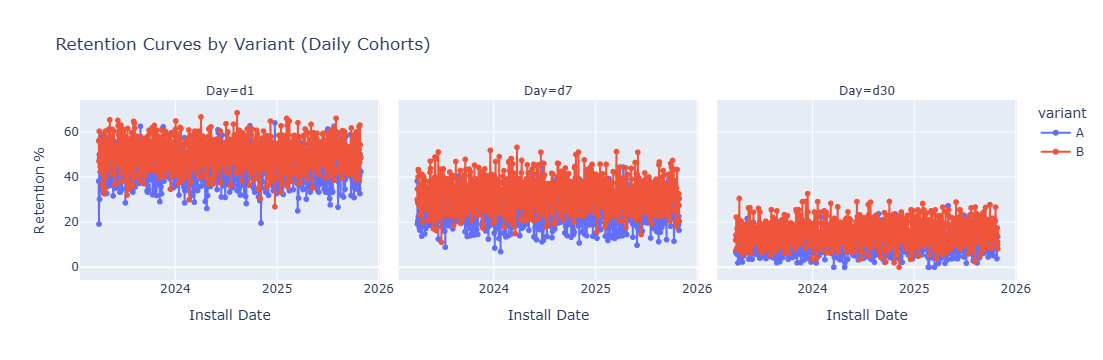

In [6]:
df_cohort = con.sql("SELECT * FROM cohort_daily ORDER BY install_day, variant").df()

# Melt for easier plotting
df_melt = df_cohort.melt(
    id_vars=['install_day', 'variant'],
    value_vars=['retention_d1_pct', 'retention_d7_pct', 'retention_d30_pct'],
    var_name='Day',
    value_name='Retention %'
)

df_melt['Day'] = df_melt['Day'].str.replace('retention_', '').str.replace('_pct', '')

fig = px.line(
    df_melt,
    x='install_day',
    y='Retention %',
    color='variant',
    facet_col='Day',
    title='Retention Curves by Variant (Daily Cohorts)',
    labels={'install_day': 'Install Date'},
    markers=True
)

fig.update_layout(hovermode='x unified')
fig.show()

#### Per-day uplift bar chart (most readable view)

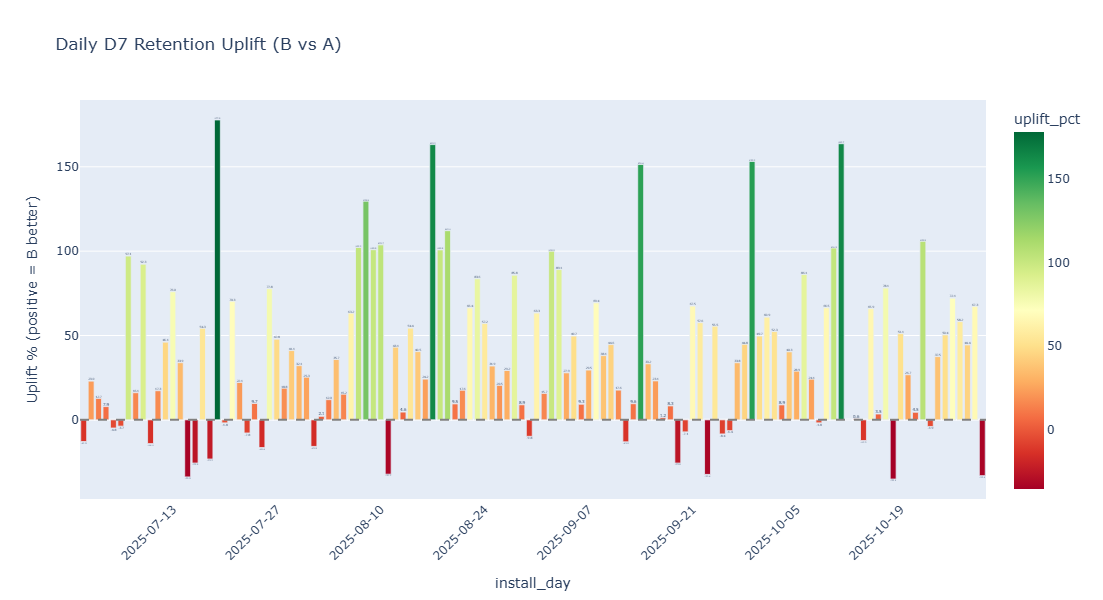

In [27]:
pivot = df_cohort.pivot_table(
    index='install_day',
    columns='variant',
    values='retention_d7_pct',
    aggfunc='first'
)

pivot['uplift_pct'] = (pivot.get('B') / pivot.get('A') - 1) * 100

uplift_df = pivot[['uplift_pct']].reset_index().dropna()
uplift_df = uplift_df.sort_values('install_day', ascending=False)

# Add cohort size from A
size_a = df_cohort[df_cohort['variant']=='A'][['install_day', 'cohort_size']] \
         .rename(columns={'cohort_size': 'cohort_size_A'})
uplift_df = uplift_df.merge(size_a, on='install_day', how='left')

fig = px.bar(
    uplift_df,
    x='install_day',
    y='uplift_pct',
    title='Daily D7 Retention Uplift (B vs A)',
    text_auto='.1f',
    color='uplift_pct',
    color_continuous_scale='RdYlGn',
    hover_data=['cohort_size_A']
)

fig.update_traces(textposition='auto', marker_line_width=0.8)
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_tickformat='%Y-%m-%d',
    height=600, width=1100,
    yaxis_title='Uplift % (positive = B better)',
    bargap=0.2
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.show()

#### Overall summary statistics for the selected period

In [10]:
summary = df_cohort.groupby('variant')[
    ['retention_d7_pct', 'retention_d30_pct', 'avg_revenue', 'payer_conversion_pct']
].mean().round(2)

print("Average performance in selected period:")
display(summary)

overall_uplift_d7 = (summary.loc['B', 'retention_d7_pct'] / summary.loc['A', 'retention_d7_pct'] - 1) * 100
print(f"\nAverage D7 retention uplift (B vs A): {overall_uplift_d7:.1f}%")

Average performance in selected period:


,retention_d7_pct,retention_d30_pct,avg_revenue,payer_conversion_pct
variant,,,,
A,25.1,10.13,0.50,2.75
B,32.3,15.39,0.58,5.04



Average D7 retention uplift (B vs A): 28.7%


#### Key Takeaways from Recent Cohorts

**Variant B (new streak rewards) outperforms A across all KPIs:**

- D7 Retention: **31.95% vs 24.49%** → **+30.5% relative uplift**
- D30 Retention: **16.27% vs 10.29%** → **+58.1% relative uplift**
- Avg Revenue per User: **$0.58 vs $0.49** → **+18.4%**
- Payer Conversion: **5.20% vs 3.09%** → **+68.3%**

**Business recommendation**  
→ Strong case to **roll out Variant B** to all users  
→ Monitor post-rollout D30+ retention to confirm long-term effect  
→ Consider follow-up test: optimize streak rewards (e.g. different multipliers, timing, or combination with other mechanics)
